# Explanatory Data Analysis and Visualization

1. Data Overview and Structure (e.g., numerical, categorical...)
2. Quality Assessment (e.g., missing value, duplicate data, data type validation, ...)
3. Univariate Analysis (e.g., basic statistics, distribution checks, outlier detection, ...)
4. Bivariate/Multivariate Analysis (e.g., correlation, scatter plots, categorical analysis)
5. Feature Engineering Exploration (e.g., skewness correction (transformation), categorical cardinality (encoding), class imbalance)


In [1]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='joblib')
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

## 1. Data Overview and Structure

In [3]:
print('--- Data Types and Info ---')
df.info()

print('\n--- Descriptive Statistics ---')
display(df.describe())

--- Data Types and Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel               

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [4]:
# Identify numerical and categorical columns
numerical_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'EmployeeCount', 'EmployeeNumber', 'StandardHours'
]

categorical_cols = [
    'BusinessTravel', 'Department', 'Education', 'EducationField', 
    'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 
    'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 
    'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 
    'WorkLifeBalance', 'Over18'
]

all_processed_cols = numerical_cols + categorical_cols + ['Attrition'] 
missing = [c for c in df.columns if c not in all_processed_cols]
if missing:
    print(f"Missing Col: {missing}")

print(f'Len(Numerical Columns): {len(numerical_cols)}')
print(f'Len(Categorical Columns): {len(categorical_cols)}')

Len(Numerical Columns): 17
Len(Categorical Columns): 17


## Quality Assessment

In [5]:
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing Values: 0
Duplicate Rows: 0


In [6]:
# Categorical Consistency Check
print("Current categorical columns:")
for col in categorical_cols:
    unique_values = df[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Current categorical columns:
Unique values in column 'BusinessTravel': <StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Unique values in column 'Department': <StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
Unique values in column 'Education': [2 1 4 3 5]
Unique values in column 'EducationField': <StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str
Unique values in column 'EnvironmentSatisfaction': [2 3 4 1]
Unique values in column 'Gender': <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique values in column 'JobInvolvement': [3 2 4 1]
Unique values in column 'JobLevel': [2 1 3 4 5]
Unique values in column 'JobRole': <StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                

In [7]:
# Check constant columns (columns with only one unique value that does not help with analysis)
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Dataframe shape before removing constant columns: {df.shape}")
print(f"Constant columns: {constant_columns}")

# Remove constant columns
df.drop(columns=constant_columns, inplace=True)
print(f"Dataframe shape after removing constant columns: {df.shape}")

Dataframe shape before removing constant columns: (1470, 35)
Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Dataframe shape after removing constant columns: (1470, 32)


In [8]:
# Check unique identifier
if df['EmployeeNumber'].is_unique:
    print("EmployeeNumber is a unique identifier.")
    df.set_index('EmployeeNumber', inplace=True)

print(f"Dataframe shape after removing constant columns: {df.shape}")

EmployeeNumber is a unique identifier.
Dataframe shape after removing constant columns: (1470, 31)


## Univariate Analysis

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

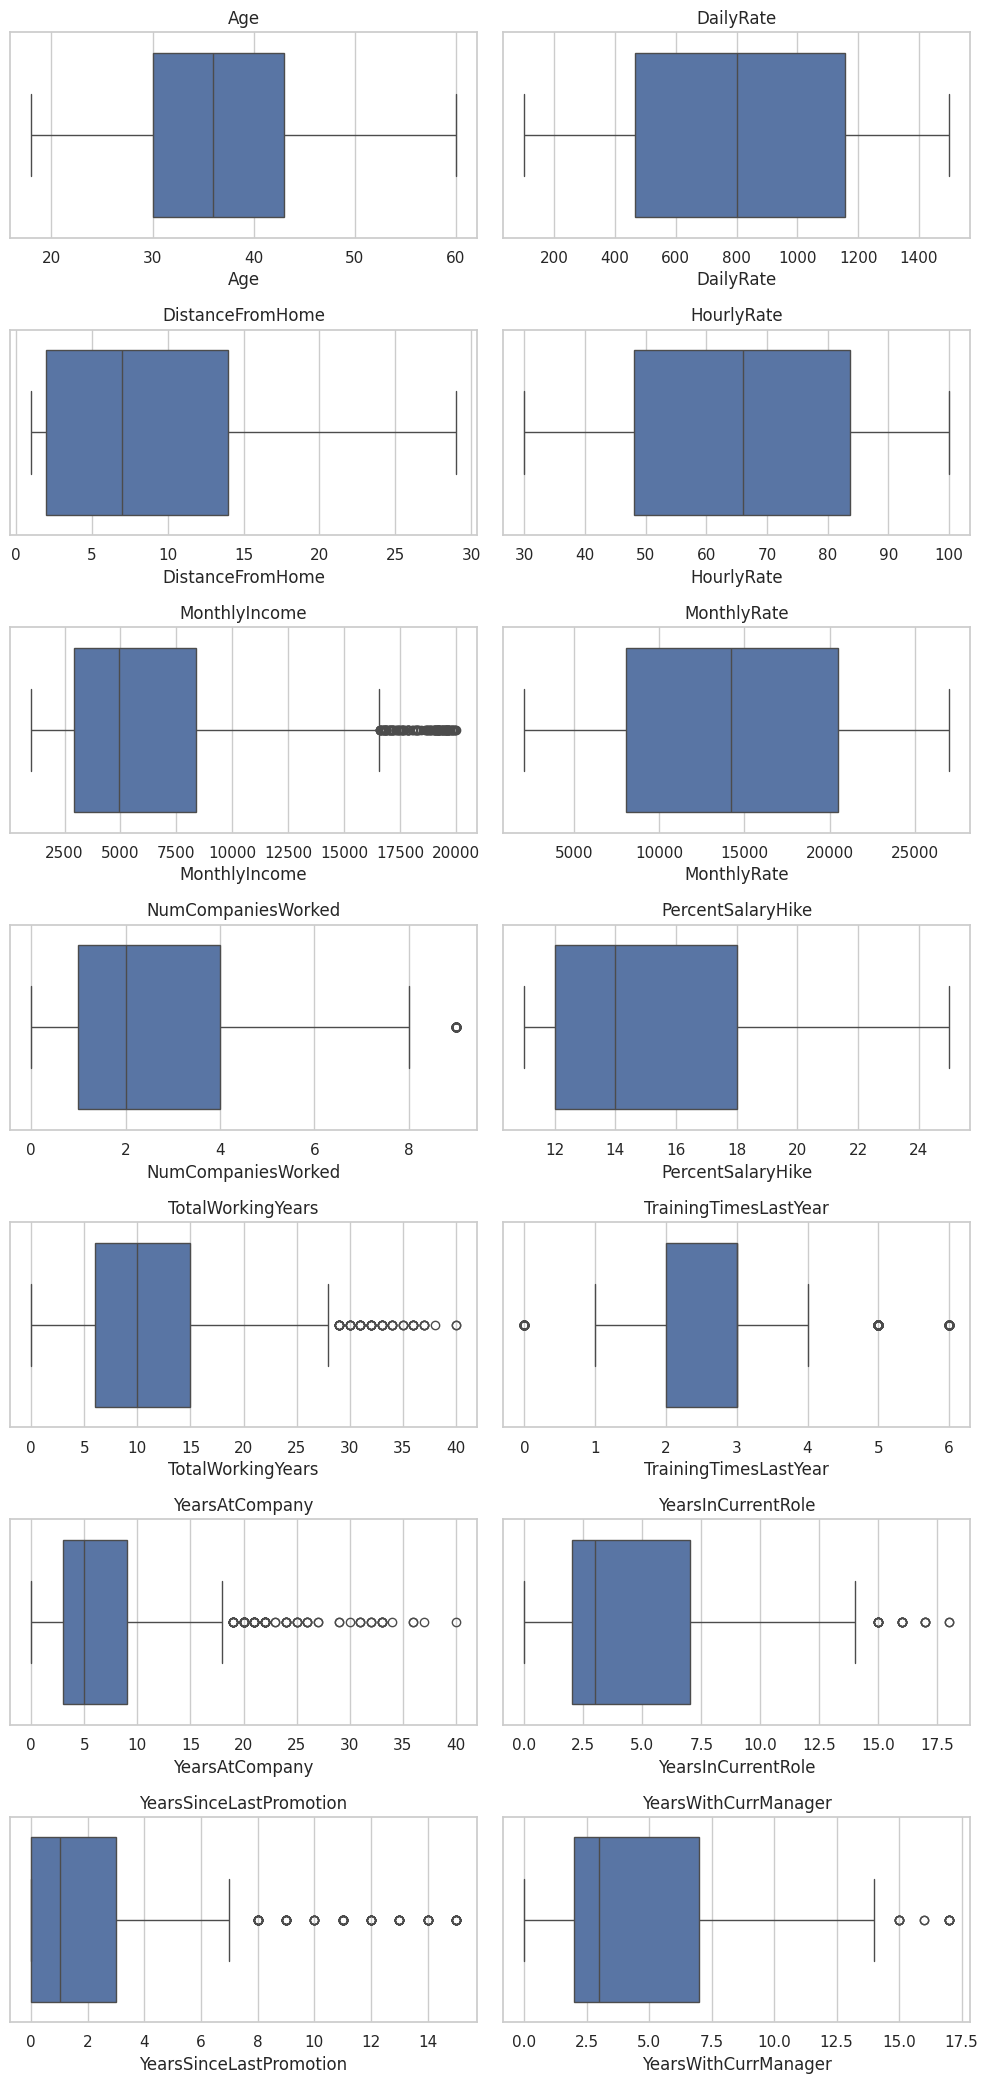

In [9]:
# Filter only necessary numerical_cols
numerical_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 
    'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

n = len(numerical_cols)
cols = 2  
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 3 * rows))
for i, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'{col}')

plt.tight_layout()
plt.show()


In [10]:
# Winsorization function to cap outliers
def winsorize_series(series, lower_percentile=0.01, upper_percentile=0.99):
    lower_bound = series.quantile(lower_percentile)
    upper_bound = series.quantile(upper_percentile)
    return series.clip(lower=lower_bound, upper=upper_bound)

winsorize_series(df['YearsInCurrentRole'], lower_percentile=0.01, upper_percentile=0.99)
winsorize_series(df['YearsWithCurrManager'], lower_percentile=0.01, upper_percentile=0.99)
winsorize_series(df['NumCompaniesWorked'], lower_percentile=0.01, upper_percentile=0.99)

# Log transformation: MonthlyIncome, Total Working Years, YearsAtCompany, YearsSinceLastPromotion
df['MonthlyIncome'] = np.log1p(df['MonthlyIncome'])
df['TotalWorkingYears'] = np.log1p(df['TotalWorkingYears'])
df['YearsAtCompany'] = np.log1p(df['YearsAtCompany'])
df['YearsSinceLastPromotion'] = np.log1p(df['YearsSinceLastPromotion'])

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

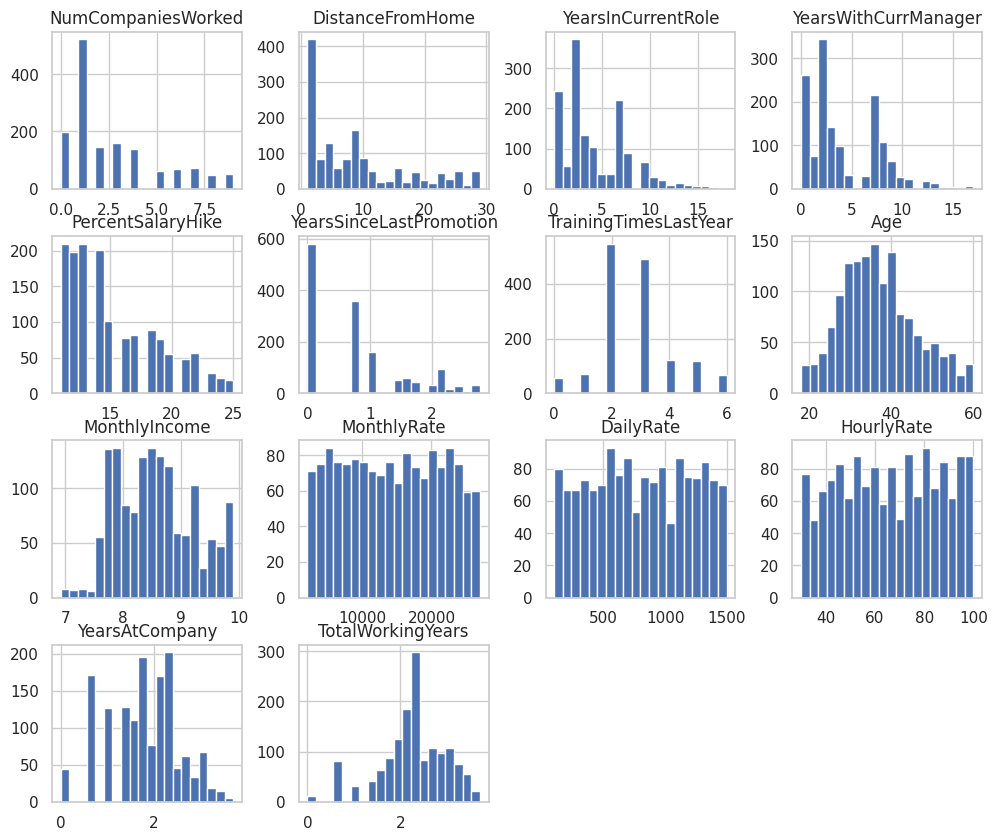

In [11]:
skew_summary = df[numerical_cols].skew().sort_values(ascending=False)
df[skew_summary.index].hist(bins=20, figsize=(12, 10))
plt.show()

In [12]:
# Identify skewed features (threshold > 0.75 or < -0.75)
skewness = df[numerical_cols].skew().sort_values(ascending=False)
skewness = skewness[abs(skewness) > 0.75]
print(skewness)

NumCompaniesWorked      1.026471
DistanceFromHome        0.958118
YearsInCurrentRole      0.917363
YearsWithCurrManager    0.833451
PercentSalaryHike       0.821128
dtype: float64


Skewness after processing:
DistanceFromHome       -0.007468
NumCompaniesWorked      0.014814
YearsInCurrentRole     -0.060849
YearsWithCurrManager   -0.067565
PercentSalaryHike       0.116250
dtype: float64


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

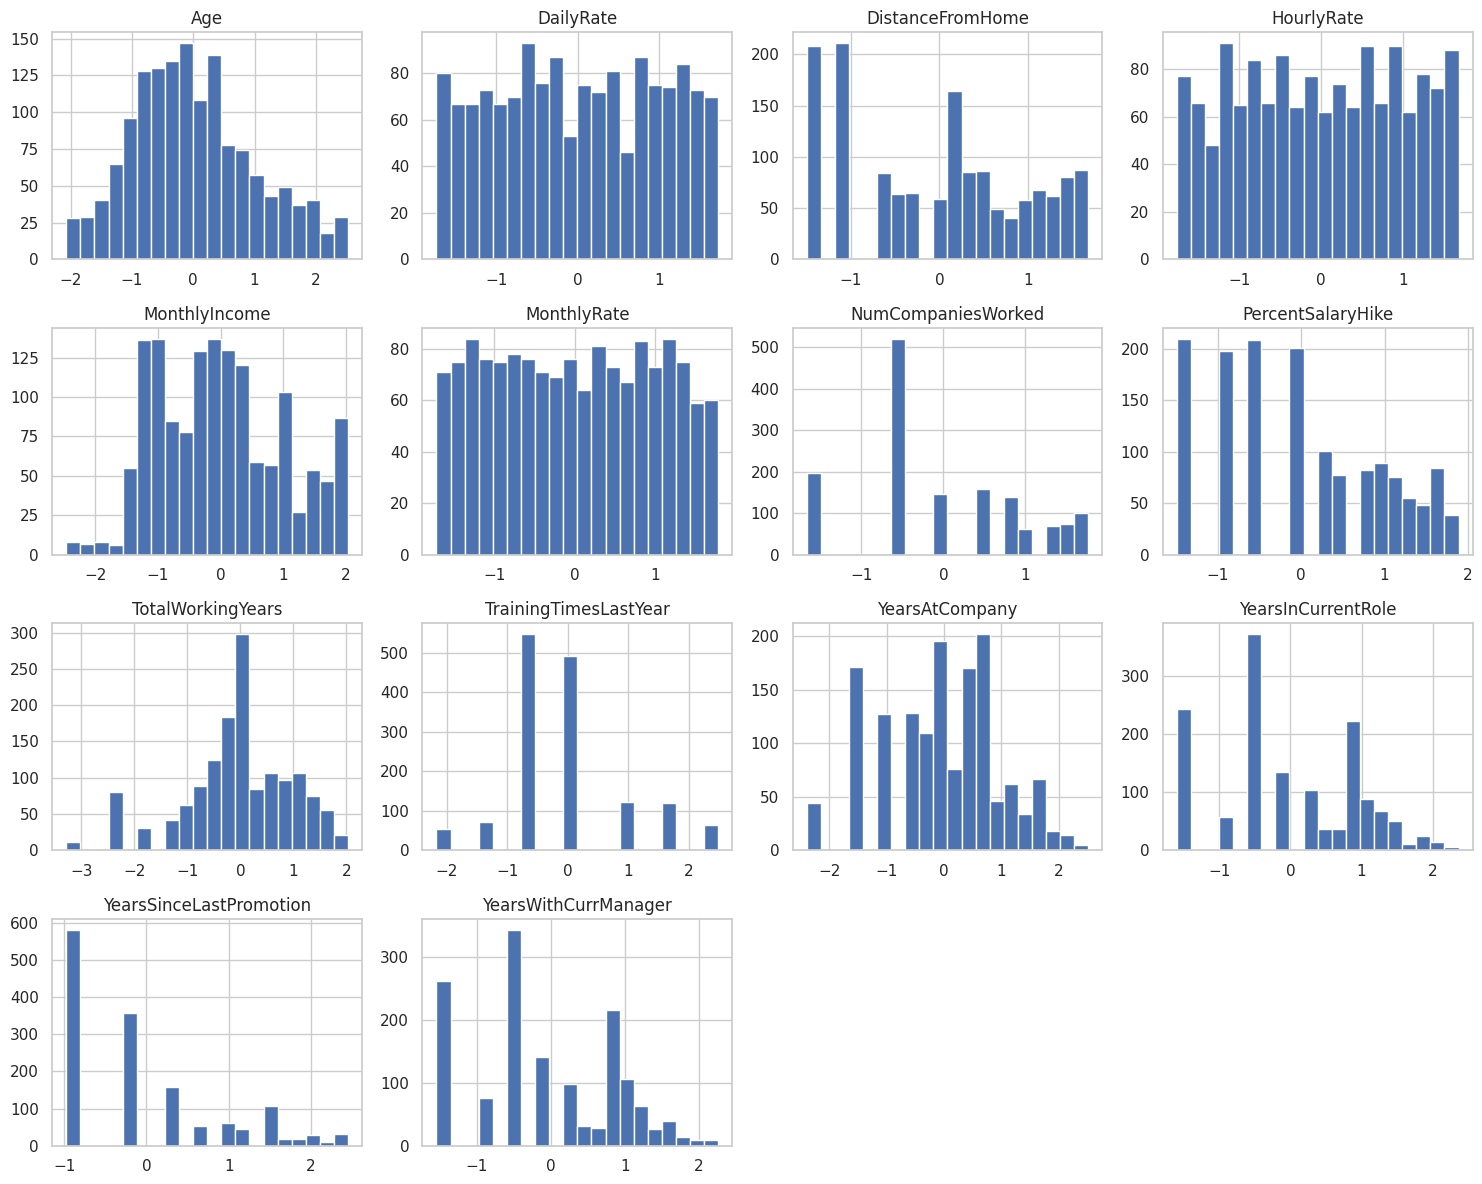

In [13]:
## Deal with skewness 
skewed_cols = ['DistanceFromHome', 'NumCompaniesWorked', 'YearsInCurrentRole', 'YearsWithCurrManager','PercentSalaryHike']


numerical_features = [col for col in numerical_cols if col in df.columns]

pt = PowerTransformer(method='yeo-johnson')
df[skewed_cols] = pt.fit_transform(df[skewed_cols])

scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])


print("Skewness after processing:")
print(df[skewed_cols].skew())

df[numerical_features].hist(bins=20, figsize=(15, 12))
plt.tight_layout()
plt.show()


## Bivariate/Multivariate Analysis

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

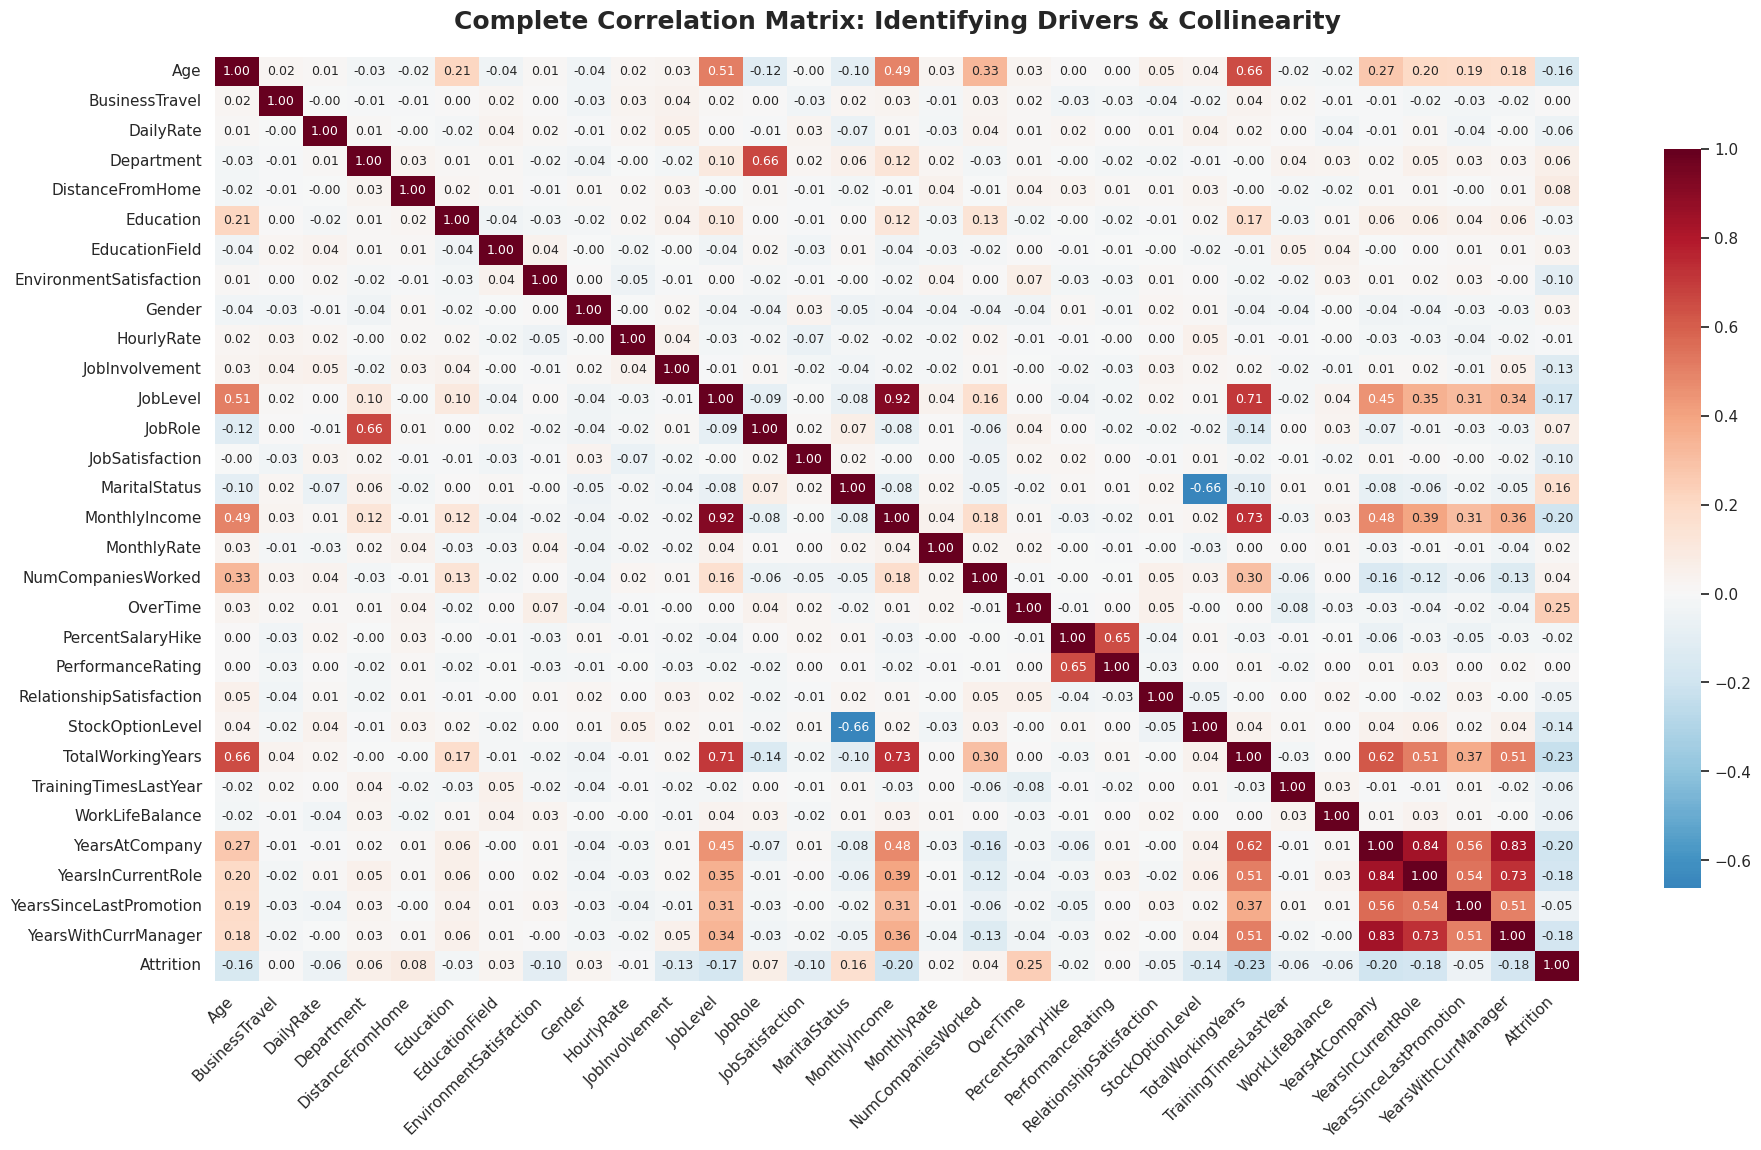

In [14]:
## Correlation Analysis
corr_df = df.copy()

corr_df['Attrition'] = corr_df['Attrition'].map({'Yes': 1, 'No': 0})
corr_df['OverTime'] = corr_df['OverTime'].map({'Yes': 1, 'No': 0})
corr_df['Gender'] = corr_df['Gender'].map({'Male': 1, 'Female': 0})


categorical_cols = [
    'BusinessTravel', 'Department', 'EducationField', 'MaritalStatus', 'JobRole'
]

for col in categorical_cols:
    if col in corr_df.columns:
        corr_df[col] = corr_df[col].astype('category').cat.codes


cols_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18']  
final_df = corr_df.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

all_cols = [c for c in final_df.columns if c != 'Attrition'] + ['Attrition']
final_corr_matrix = final_df[all_cols].corr()


plt.figure(figsize=(22, 12))

# Create mask to hide upper triangle 
# mask = np.triu(np.ones_like(final_corr_matrix, dtype=bool))

sns.heatmap(
    final_corr_matrix, 
    # mask=mask,
    annot=True,          
    fmt='.2f',           
    cmap='RdBu_r',       
    center=0,            
    annot_kws={"size": 9},
    cbar_kws={"shrink": .8}
)

plt.title('Complete Correlation Matrix: Identifying Drivers & Collinearity', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
# Identify highly collinear features (|correlation| > 0.75)
import numpy as np
import pandas as pd

numeric_df = df.select_dtypes(include=[np.number])

df_corr = numeric_df.corr().abs()
upper = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))

threshold = 0.7
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
    .query('correlation > @threshold')
    .sort_values(by='correlation', ascending=False)
 )

display(high_corr_pairs)

# Suggested features to drop due to high collinearity
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    to_drop.add(row['feature_2'])
print("Suggested features to drop due to high collinearity:", to_drop)

,feature_1,feature_2,correlation
170,JobLevel,MonthlyIncome,0.920046
457,YearsAtCompany,YearsInCurrentRole,0.841131
459,YearsAtCompany,YearsWithCurrManager,0.832470
482,YearsInCurrentRole,YearsWithCurrManager,0.732958
223,MonthlyIncome,TotalWorkingYears,0.732692
177,JobLevel,TotalWorkingYears,0.705382


Suggested features to drop due to high collinearity: {'TotalWorkingYears', 'MonthlyIncome', 'YearsWithCurrManager', 'YearsInCurrentRole'}


In [16]:
# VIF (Variance Inflation Factor) for identifying multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_df = df.select_dtypes(include=[float, int]).copy()
if 'Attrition_Num' in vif_df.columns:
    vif_df = vif_df.drop(columns=['Attrition_Num'])

vif_data = pd.DataFrame()
vif_data['feature'] = vif_df.columns
vif_data['VIF'] = [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
display(vif_data.sort_values('VIF', ascending=False))

,feature,VIF
13,PerformanceRating,50.582520
7,JobLevel,28.073373
18,WorkLifeBalance,15.496808
6,JobInvolvement,14.846477
3,Education,9.135380
14,RelationshipSatisfaction,7.226378
4,EnvironmentSatisfaction,7.089752
8,JobSatisfaction,6.958011
9,MonthlyIncome,6.935711
19,YearsAtCompany,6.616424


In [17]:
# Remove high collinearity features
cols_to_remove = ['JobLevel', 'YearsAtCompany', 'WorkLifeBalance','MonthlyIncome', 'PerformanceRating','JobInvolvement', 'HourlyRate', 'DailyRate']
df = df.drop(columns=cols_to_remove, errors='ignore')
print(f"Removed columns: {cols_to_remove}")
print(f"Current columns: {df.columns.tolist()}")
print(f"Dataframe shape after removing high collinearity columns: {df.shape}")

Removed columns: ['JobLevel', 'YearsAtCompany', 'WorkLifeBalance', 'MonthlyIncome', 'PerformanceRating', 'JobInvolvement', 'HourlyRate', 'DailyRate']
Current columns: ['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Dataframe shape after removing high collinearity columns: (1470, 23)


## Feature Engineering

In [18]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,NumCompaniesWorked,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1,0.446350,Yes,Travel_Rarely,Sales,-1.494085,2,Life Sciences,2,Female,Sales Executive,...,1.621331,Yes,-1.488918,1,0,-0.138921,-2.171982,0.205562,-0.973342,0.490147
2,1.322365,No,Travel_Frequently,Research & Development,0.243416,1,Life Sciences,3,Male,Research Scientist,...,-0.571302,No,1.679689,4,1,0.148411,0.155707,0.883888,-0.117271,0.909635
4,0.008343,Yes,Travel_Rarely,Research & Development,-1.031215,2,Other,4,Male,Laboratory Technician,...,1.271339,Yes,0.201133,2,0,-0.307569,0.155707,-1.596434,-0.973342,-1.550156
5,-0.429664,No,Travel_Frequently,Research & Development,-0.700347,4,Life Sciences,4,Female,Research Scientist,...,-0.571302,Yes,-1.488918,3,0,-0.138921,0.155707,0.883888,0.738799,-1.550156
7,-1.086676,No,Travel_Rarely,Research & Development,-1.031215,1,Medical,1,Male,Laboratory Technician,...,1.766182,No,-0.948760,4,1,-0.498767,0.155707,-0.446645,0.383498,-0.406881


In [19]:
# Target variable encoding
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
X = df.drop(['Attrition', 'Attrition_Num'], axis=1).copy()
y = df['Attrition_Num']

# Binary Encoding for 'OverTime' and 'Gender'
X['OverTime'] = X['OverTime'].map({'Yes': 1, 'No': 0})
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

if 'JobLevel' in X.columns:
    X = X.drop(columns='JobLevel')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Target Encoding

for col in ['JobRole', 'EducationField']:
    target_map = X_train.join(y_train).groupby(col)['Attrition_Num'].mean()
    X_train[col + '_Encoded'] = X_train[col].map(target_map)
    X_test[col + '_Encoded'] = X_test[col].map(target_map)
    X_train = X_train.drop(columns=col)
    X_test = X_test.drop(columns=col)

# One-hot encoding for remaining categorical columns 
exclude_cols = ['OverTime', 'Gender', 'JobRole_Encoded', 'EducationField_Encoded']
categorical_cols_to_encode = [col for col in X_train.select_dtypes(include='object').columns if col not in exclude_cols]
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols_to_encode, drop_first=True, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols_to_encode, drop_first=True, dtype=int)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

/tmp/ipykernel_3997030/3880020653.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_to_encode = [col for col in X_train.select_dtypes(include='object').columns if col not in exclude_cols]


In [20]:
print(X_train_encoded.shape, X_test_encoded.shape, y_train.shape, y_test.shape)

(1176, 25) (294, 25) (1176,) (294,)


## Check Class Imbalance

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

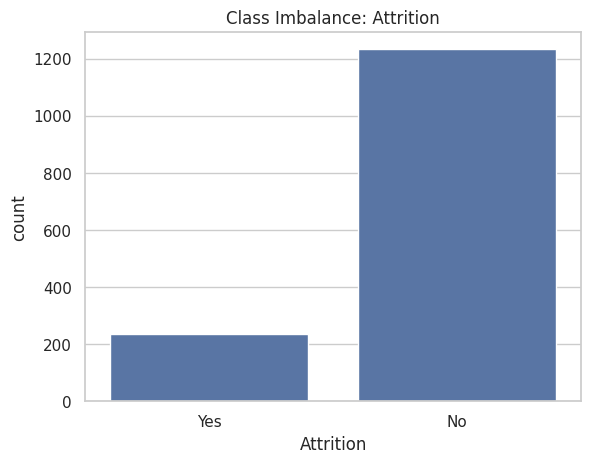

In [21]:
# Class Imbalance Check
    
sns.countplot(x='Attrition', data=df)
plt.title('Class Imbalance: Attrition')
plt.show()

In [22]:
print(f"Original class distribution: {Counter(y_train)}")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)
print(f"Class distribution after SMOTE: {Counter(y_train_resampled)}")

# use X_train_resampled and y_train_resampled for model training, and X_test, y_test for evaluation.

Original class distribution: Counter({0: 986, 1: 190})
Class distribution after SMOTE: Counter({0: 986, 1: 986})


In [23]:
print(f"\nFinal Features (Total {len(X_train_resampled.columns)}):")
print(X_train_resampled.columns.tolist())


Final Features (Total 25):
['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobRole_Encoded', 'EducationField_Encoded', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'MaritalStatus_Married', 'MaritalStatus_Single']


## Data Distribution Visualization (PCA)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

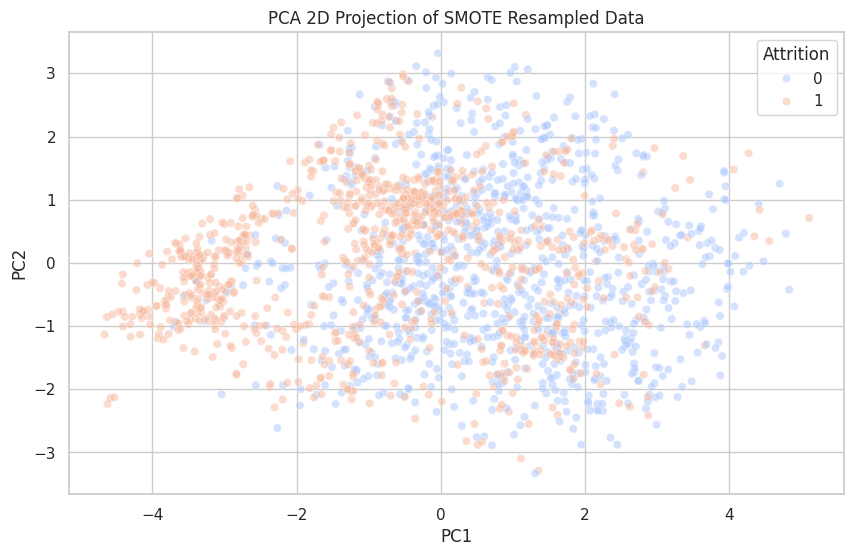

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

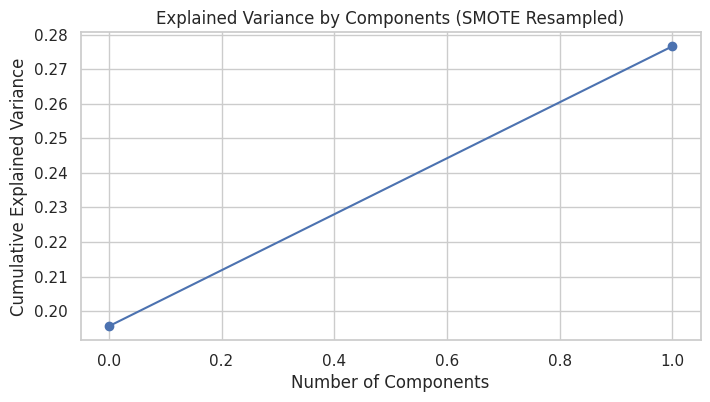


Top 5 features contributing to PC1 (Abs Value, SMOTE Resampled):
TotalWorkingYears       0.461735
YearsInCurrentRole      0.416897
YearsWithCurrManager    0.412680
Age                     0.363790
JobRole_Encoded         0.352004
Name: PC1, dtype: float64

Top 5 features contributing to PC2 (Abs Value, SMOTE Resampled):
NumCompaniesWorked         0.599316
Age                        0.357016
YearsWithCurrManager       0.320796
YearsSinceLastPromotion    0.318933
YearsInCurrentRole         0.318578
Name: PC2, dtype: float64


In [24]:
binary_cols = [col for col in X_train_resampled.columns if set(X_train_resampled[col].unique()) <= {0, 1}]
other_cols = [col for col in X_train_resampled.columns if col not in binary_cols]


scaler = StandardScaler()
X_train_resampled_scaled = X_train_resampled.copy()
X_train_resampled_scaled[other_cols] = scaler.fit_transform(X_train_resampled[other_cols])

pca = PCA(n_components=2)
pca_results_resampled = pca.fit_transform(X_train_resampled_scaled)
pca_df_resampled = pd.DataFrame(data=pca_results_resampled, columns=['PC1', 'PC2'])
pca_df_resampled['Attrition'] = y_train_resampled.values


# 2D PCA Scatter Plot for SMOTE resampled data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Attrition', data=pca_df_resampled, alpha=0.5, palette='coolwarm')
plt.title('PCA 2D Projection of SMOTE Resampled Data')
plt.show()

# Scree Plot to show explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components (SMOTE Resampled)')
plt.grid(True)
plt.show()

loadings_resampled = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=X_train_resampled_scaled.columns
)

print("\nTop 5 features contributing to PC1 (Abs Value, SMOTE Resampled):")
print(loadings_resampled['PC1'].abs().sort_values(ascending=False).head(5))
print("\nTop 5 features contributing to PC2 (Abs Value, SMOTE Resampled):")
print(loadings_resampled['PC2'].abs().sort_values(ascending=False).head(5))

### Interpretation for PCA visualization

1. PCA 2D Projection: meaning that the attrition attribute can not be clearly separated in a linear problem. We choose models that can handle non-linearity for this binary classification problem (i.e., XGBoost)

2. PC1: the major features lie in "Seniority/Tenure". PC2: Job hopping.